In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
  
def sigmoid(z):
    """
    Calcule la fonction sigmoïde de z.
    Paramètres :
        z (ndarray ou scalaire) : valeur(s) d'entrée
    Retourne :
        g (ndarray ou scalaire) : sigmoid(z), même forme que z
    """
    # ✅ SOLUTION
    g = 1 / (1 + np.exp(-z))
    return g

In [3]:
z_tmp = np.arange(-10, 11)
y = sigmoid(z_tmp)

np.set_printoptions(precision=3)
print("Entrée z | Sortie sigmoid(z)")
print(np.c_[z_tmp, y])

Entrée z | Sortie sigmoid(z)
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


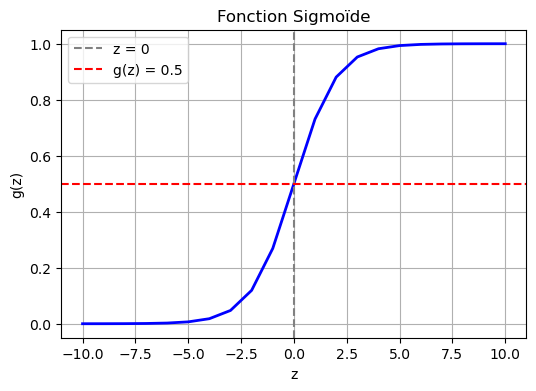

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(z_tmp, y, c="b", linewidth=2)
ax.set_title("Fonction Sigmoïde")
ax.set_ylabel('g(z)')
ax.set_xlabel('z')
ax.axvline(x=0, color='gray', linestyle='--', label='z = 0')
ax.axhline(y=0.5, color='red', linestyle='--', label='g(z) = 0.5')
ax.legend()
plt.grid(True)
plt.show()


In [5]:
def predict(z):
    """
    Applique le seuil 0.5 sur la sortie de sigmoid.
    Paramètres :
        z (ndarray) : valeurs d'entrée
    Retourne :
        predictions (ndarray) : tableau de 0 et 1
    """
    g = sigmoid(z)
    # ✅ SOLUTION : retourner 1 si g >= 0.5, sinon 0
    predictions = (g >= 0.5).astype(int)
    return predictions

# Test
z_test = np.array([-3, -1, 0, 1, 3])
print("z          :", z_test)
print("sigmoid(z) :", np.round(sigmoid(z_test), 3))
print("predict(z) :", predict(z_test))
# Résultat attendu : [0, 0, 1, 1, 1]

z          : [-3 -1  0  1  3]
sigmoid(z) : [0.047 0.269 0.5   0.731 0.953]
predict(z) : [0 0 1 1 1]


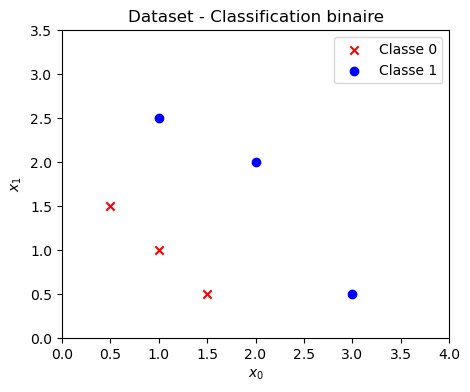

In [6]:
#part 2
X = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5],
              [3, 0.5],   [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1])

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
# ✅ SOLUTION
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red',  marker='x', label='Classe 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='o', label='Classe 1')
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_title('Dataset - Classification binaire')
ax.legend(['Classe 0', 'Classe 1'])
ax.axis([0, 4, 0, 3.5])
plt.show()

In [7]:
w = np.array([1, 1])
b = -3

# ✅ SOLUTION
z = X @ w + b          # z = X·w + b pour tous les exemples et @: multiplication matricielle 
g = sigmoid(z)         # g(z) = sigmoid(z)

print("Point | z     | g(z)  | Prédiction")
print("-" * 42)
for i in range(len(X)):
    pred = 1 if g[i] >= 0.5 else 0
    print(f"  {i+1}   | {z[i]:.2f}  | {g[i]:.3f} | {pred}")

Point | z     | g(z)  | Prédiction
------------------------------------------
  1   | -1.00  | 0.269 | 0
  2   | -1.00  | 0.269 | 0
  3   | -1.00  | 0.269 | 0
  4   | 0.50  | 0.622 | 1
  5   | 1.00  | 0.731 | 1
  6   | 0.50  | 0.622 | 1


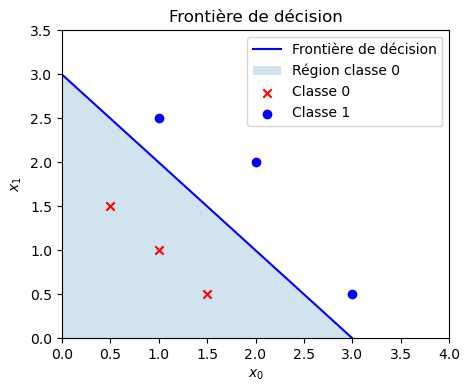

In [8]:
x0 = np.arange(0, 6)
# ✅ SOLUTION : x0 + x1 - 3 = 0  →  x1 = 3 - x0
x1 = 3 - x0

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(x0, x1, c="b", label="Frontière de décision")
ax.fill_between(x0, x1, alpha=0.2, label="Région classe 0")
# ✅ SOLUTION : afficher les points
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red',  marker='x', label='Classe 0')
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', marker='o', label='Classe 1')
ax.set_xlabel('$x_0$')
ax.set_ylabel('$x_1$')
ax.set_title('Frontière de décision')
ax.axis([0, 4, 0, 3.5])
ax.legend()
plt.show()

# Réponses aux questions :
# - La droite x1 = 3-x0 coupe l'axe x1 en x1=3 (quand x0=0)
#   et l'axe x0 en x0=3 (quand x1=0)
# - Oui, les points classe 0 sont dans la région ombrée (z < 0)
# - Oui, les points classe 1 sont au-dessus de la frontière (z > 0)

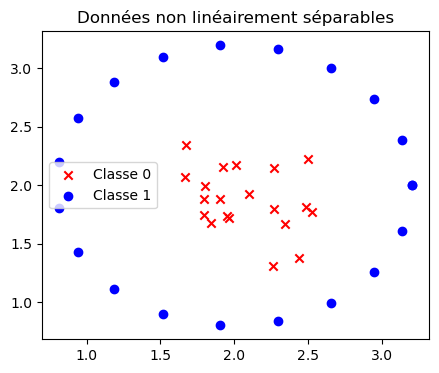

In [9]:
np.random.seed(1)
r0 = np.random.randn(20, 2) * 0.3 + [2, 2]   # classe 0 : centre
r1_angles = np.linspace(0, 2*np.pi, 20)
r1 = np.column_stack([2 + 1.2*np.cos(r1_angles),
                      2 + 1.2*np.sin(r1_angles)])  # classe 1 : cercle

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(r0[:, 0], r0[:, 1], c='red',  marker='x', label='Classe 0')
ax.scatter(r1[:, 0], r1[:, 1], c='blue', marker='o', label='Classe 1')
ax.set_title("Données non linéairement séparables")
ax.legend()
plt.show()

# Observation : Aucune droite ne peut séparer ces deux classes.
# En ajoutant x0² et x1², la frontière devient un cercle x0² + x1² = r²

In [10]:
#part 3
def logistic_loss(y_hat, y):
    """
    Calcule la perte logistique pour un seul exemple.
    Paramètres :
        y_hat (float) : prédiction du modèle, entre 0 et 1
        y     (float) : valeur cible, 0 ou 1
    Retourne :
        loss (float) : valeur de la perte
    """
    # ✅ SOLUTION
    loss = -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)
    return loss

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Test cas y = 1
print("=== Cas y = 1 ===")
for y_hat in [1.0, 0.5, 0.1, 0.01]:
    print(f"y_hat = {y_hat:.2f} | perte = {logistic_loss(y_hat, 1):.4f}")

# Test cas y = 0
print("\n=== Cas y = 0 ===")
for y_hat in [0.0, 0.5, 0.9, 0.99]:
    print(f"y_hat = {y_hat:.2f} | perte = {logistic_loss(y_hat, 0):.4f}")

=== Cas y = 1 ===
y_hat = 1.00 | perte = nan
y_hat = 0.50 | perte = 0.6931
y_hat = 0.10 | perte = 2.3026
y_hat = 0.01 | perte = 4.6052

=== Cas y = 0 ===
y_hat = 0.00 | perte = nan
y_hat = 0.50 | perte = 0.6931
y_hat = 0.90 | perte = 2.3026
y_hat = 0.99 | perte = 4.6052


C:\Users\diikr\AppData\Local\Temp\ipykernel_14120\374835709.py:12: RuntimeWarning: divide by zero encountered in log
  loss = -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)
C:\Users\diikr\AppData\Local\Temp\ipykernel_14120\374835709.py:12: RuntimeWarning: invalid value encountered in scalar multiply
  loss = -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)


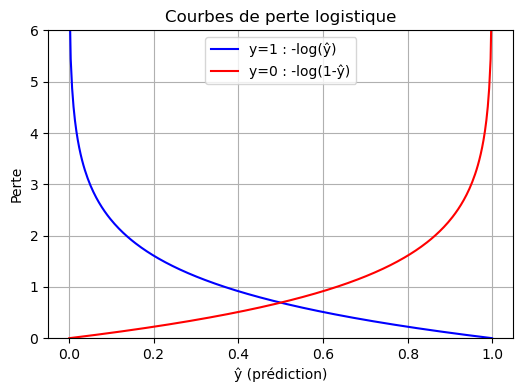

In [13]:
y_hat   = np.linspace(0.001, 0.999, 300)
loss_y1 = -np.log(y_hat)        # Perte quand y = 1
loss_y0 = -np.log(1 - y_hat)    # Perte quand y = 0

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(y_hat, loss_y1, c="blue", label="y=1 : -log(ŷ)")
ax.plot(y_hat, loss_y0, c="red",  label="y=0 : -log(1-ŷ)")
ax.set_xlabel('ŷ (prédiction)')
ax.set_ylabel('Perte')
ax.set_title('Courbes de perte logistique')
ax.set_ylim(0, 6)
ax.legend()
plt.grid(True)
plt.show()

In [14]:
def compute_cost_logistic(X, y, w, b):
    """
    Calcule la fonction de coût logistique.
    Paramètres :
        X (ndarray) : matrice des features, shape (m, n)
        y (ndarray) : vecteur des cibles, shape (m,)
        w (ndarray) : vecteur des poids, shape (n,)
        b (float)   : biais
    Retourne :
        cost (float) : valeur du coût
    """
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i    = np.dot(w, X[i]) + b    # ✅ z_i = w . x_i + b
        f_i    = sigmoid(z_i)           # ✅ f_i = sigmoid(z_i)
        cost  += -y[i]*np.log(f_i) - (1 - y[i])*np.log(1 - f_i)  # ✅ perte i
    cost = cost / m                     # ✅ normaliser par m
    return cost

In [15]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])

# Test avec w=0, b=0 (modèle non entraîné)
cost1 = compute_cost_logistic(x_train.reshape(-1, 1), y_train,
                               np.array([0.]), 0.)
print(f"Coût avec w=0, b=0  : {cost1:.4f}")

# Test avec de bons paramètres
cost2 = compute_cost_logistic(x_train.reshape(-1, 1), y_train,
                               np.array([1.]), -3.)
print(f"Coût avec w=1, b=-3 : {cost2:.4f}")

# Réponses :
# - cost2 < cost1 → w=1, b=-3 est meilleur car il sépare bien les classes
# - Avec w=0, b=0 : g(0) = 0.5 pour tous les exemples → modèle incertain
# - Un coût proche de 0 signifie que le modèle prédit correctement
#   chaque exemple avec une probabilité proche de 1 (si y=1) ou 0 (si y=0)

Coût avec w=0, b=0  : 0.6931
Coût avec w=1, b=-3 : 0.2704


In [16]:
#part 4

X_train = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5],
                    [3, 0.5],   [2, 2], [1, 2.5]])
y_train = np.array([0, 0, 0, 1, 1, 1])

w_tmp = np.array([1, 1])
b_tmp = -3
print(compute_cost_logistic(X_train, y_train, w_tmp, b_tmp))
# Résultat attendu : 0.3668667864055175

0.36686678640551745


In [17]:
w = np.array([1, 1])
cost1 = compute_cost_logistic(X_train, y_train, w, -3)
cost2 = compute_cost_logistic(X_train, y_train, w, -4)
print(f"Coût pour b = -3 : {cost1:.4f}")
print(f"Coût pour b = -4 : {cost2:.4f}")
# b=-3 a le coût le plus bas → c'est le meilleur modèle

Coût pour b = -3 : 0.3669
Coût pour b = -4 : 0.5037


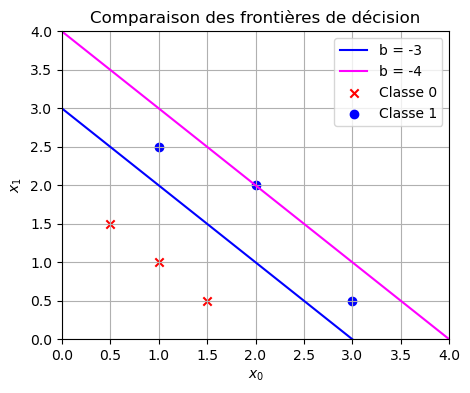

In [18]:
x0    = np.arange(0, 6)
x1_b3 = 3 - x0   # frontière pour b = -3
x1_b4 = 4 - x0   # frontière pour b = -4

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.plot(x0, x1_b3, c="blue",    label="b = -3")
ax.plot(x0, x1_b4, c="magenta", label="b = -4")
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
           c='red',  marker='x', label='Classe 0')
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
           c='blue', marker='o', label='Classe 1')
ax.axis([0, 4, 0, 4])
ax.set_xlabel('$x_0$') ; ax.set_ylabel('$x_1$')
ax.set_title('Comparaison des frontières de décision')
ax.legend() ; plt.grid(True) ; plt.show()

# Réponses :
# - b=-3 sépare mieux les deux classes (coût plus bas = 0.3669)
# - Oui, le modèle au coût le plus bas correspond à la meilleure frontière
# - Conclusion : minimiser J(w,b) revient à trouver la meilleure frontière

In [20]:
#part5
def compute_gradient_logistic(X, y, w, b):
    m, n  = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        f_wb_i = sigmoid(np.dot(w, X[i]) + b)  # ✅ sigmoid(w·x_i + b)
        err_i  = f_wb_i - y[i]                  # ✅ f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += err_i * X[i, j]         # ✅ err_i * X[i,j]
        dj_db += err_i                           # ✅ err_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m
    return dj_db, dj_dw

# Vérification
X_tmp = np.array([[0.5,1.5],[1,1],[1.5,0.5],[3,0.5],[2,2],[1,2.5]])
y_tmp = np.array([0, 0, 0, 1, 1, 1])
w_tmp = np.array([2., 3.]) ; b_tmp = 1.
dj_db, dj_dw = compute_gradient_logistic(X_tmp, y_tmp, w_tmp, b_tmp)
print(f"dj_db : {dj_db}")
print(f"dj_dw : {dj_dw.tolist()}")
# Attendu : dj_db = 0.4986...  dj_dw = [0.4983..., 0.4988...]

dj_db : 0.49861806546328574
dj_dw : [0.498333393278696, 0.49883942983996693]


In [21]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_db, dj_dw = compute_gradient_logistic(X, y, w, b)  # ✅ gradient
        w = w - alpha * dj_dw                                   # ✅ maj w
        b = b - alpha * dj_db                                   # ✅ maj b
        J_history.append(compute_cost_logistic(X, y, w, b))
        if i % (num_iters // 10) == 0:
            print(f"Itération {i:5d} : Coût = {J_history[-1]:.6f}")

    return w, b, J_history

In [22]:
w_init = np.zeros_like(X_train[0])
b_init = 0. ; alpha = 0.1 ; iters = 10000

w_out, b_out, J_hist = gradient_descent(X_train, y_train,
                                         w_init, b_init, alpha, iters)
print(f"\nParamètres appris : w = {w_out}, b = {b_out:.4f}")

Itération     0 : Coût = 0.684610
Itération  1000 : Coût = 0.159098
Itération  2000 : Coût = 0.084601
Itération  3000 : Coût = 0.057053
Itération  4000 : Coût = 0.042908
Itération  5000 : Coût = 0.034338
Itération  6000 : Coût = 0.028604
Itération  7000 : Coût = 0.024502
Itération  8000 : Coût = 0.021424
Itération  9000 : Coût = 0.019030

Paramètres appris : w = [5.281 5.078], b = -14.2224


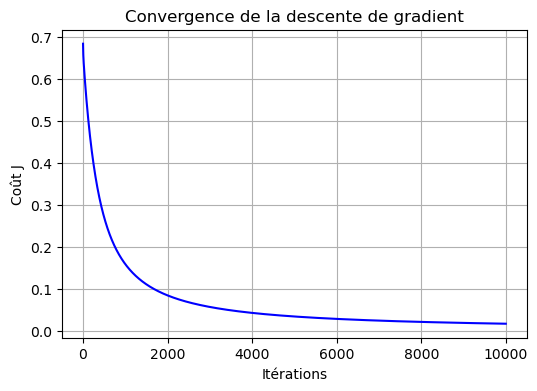

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(J_hist, c="blue")
ax.set_title("Convergence de la descente de gradient")
ax.set_xlabel("Itérations") ; ax.set_ylabel("Coût J")
plt.grid(True) ; plt.show()

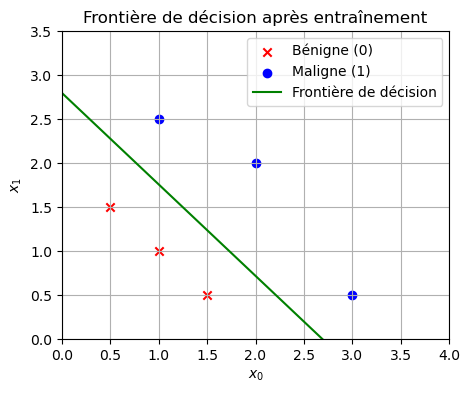

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1],
           c='red',  marker='x', label='Bénigne (0)')
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1],
           c='blue', marker='o', label='Maligne (1)')
x0_vals = np.linspace(0, 4, 100)
x1_vals = -(w_out[0] * x0_vals + b_out) / w_out[1]
ax.plot(x0_vals, x1_vals, c='green', label='Frontière de décision')
ax.set_xlabel('$x_0$') ; ax.set_ylabel('$x_1$')
ax.set_title('Frontière de décision après entraînement')
ax.axis([0, 4, 0, 3.5]) ; ax.legend() ; plt.grid(True) ; plt.show()

# Réponses :
# - Oui, le coût diminue à chaque itération (courbe décroissante)
# - Le coût se stabilise vers ~5000-6000 itérations
# - Oui, la frontière sépare correctement les deux classes

In [25]:
#part 6

from sklearn.linear_model import LogisticRegression

# ✅ SOLUTION
lr_model = LogisticRegression()        # créer le modèle
lr_model.fit(X_train, y_train)         # entraîner

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
# ✅ SOLUTION
y_pred   = lr_model.predict(X_train)       # prédire les classes
accuracy = lr_model.score(X_train, y_train) # calculer l'accuracy

print("Prédictions      :", y_pred)
print("Vraies étiquettes:", y_train)
print(f"Accuracy : {accuracy * 100:.1f}%")
# Résultat attendu : Accuracy : 100.0%

Prédictions      : [0 0 0 1 1 1]
Vraies étiquettes: [0 0 0 1 1 1]
Accuracy : 100.0%


In [27]:
print(f"Paramètres sklearn : w = {lr_model.coef_[0]}, b = {lr_model.intercept_[0]:.4f}")
print(f"Paramètres manuels : w = {w_out}, b = {b_out:.4f}")

# Réponses :
# - Les paramètres ne sont PAS exactement identiques
# - Différence car Sklearn utilise L-BFGS (algo optimisé)
#   et ajoute une régularisation L2 par défaut (C=1)
# - Sklearn est préférable en pratique : plus rapide, plus précis,
#   gère automatiquement la convergence et la régularisation

Paramètres sklearn : w = [0.904 0.736], b = -2.3337
Paramètres manuels : w = [5.281 5.078], b = -14.2224


In [28]:
y_proba = lr_model.predict_proba(X_train)
print("Probabilités prédites (classe 0 | classe 1) :")
for i in range(len(X_train)):
    print(f"  Point {i+1} : P(y=0) = {y_proba[i,0]:.3f} | "
          f"P(y=1) = {y_proba[i,1]:.3f} | Prédiction = {y_pred[i]}")

# Réponses :
# - Pour les points bien classifiés, les probabilités sont proches de 0 ou 1
# - Le point le moins certain est celui dont les probas sont les plus proches de 0.5

Probabilités prédites (classe 0 | classe 1) :
  Point 1 : P(y=0) = 0.685 | P(y=1) = 0.315 | Prédiction = 0
  Point 2 : P(y=0) = 0.667 | P(y=1) = 0.333 | Prédiction = 0
  Point 3 : P(y=0) = 0.648 | P(y=1) = 0.352 | Prédiction = 0
  Point 4 : P(y=0) = 0.322 | P(y=1) = 0.678 | Prédiction = 1
  Point 5 : P(y=0) = 0.280 | P(y=1) = 0.720 | Prédiction = 1
  Point 6 : P(y=0) = 0.399 | P(y=1) = 0.601 | Prédiction = 1


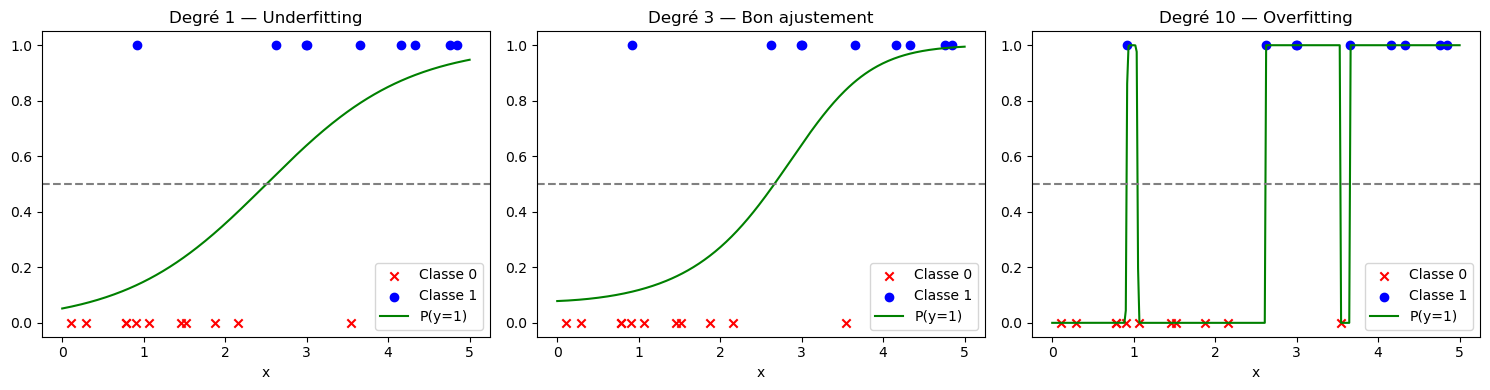

In [29]:
#part 7

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

np.random.seed(42)
X_1d = np.sort(np.random.uniform(0, 5, 20)).reshape(-1, 1)
y_1d = (X_1d.flatten() > 2.5).astype(int)
y_1d[[5, 14]] = 1 - y_1d[[5, 14]]   # bruit
x_plot = np.linspace(0, 5, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titres  = ["Degré 1 — Underfitting",
           "Degré 3 — Bon ajustement",
           "Degré 10 — Overfitting"]
configs = [(1, 1), (3, 1), (10, 1e6)]

for ax, (degree, C_val), titre in zip(axes, configs, titres):
    # ✅ SOLUTION
    model = Pipeline([
        ('poly', PolynomialFeatures(degree)),
        ('lr',   LogisticRegression(max_iter=10000, C=C_val))
    ])
    model.fit(X_1d, y_1d)             # ✅ entraîner
    proba = model.predict_proba(x_plot)[:, 1]  # ✅ P(y=1)

    ax.scatter(X_1d[y_1d==0], y_1d[y_1d==0],
               c='red',  marker='x', label='Classe 0')
    ax.scatter(X_1d[y_1d==1], y_1d[y_1d==1],
               c='blue', marker='o', label='Classe 1')
    ax.plot(x_plot, proba, c='green', label='P(y=1)')
    ax.axhline(y=0.5, color='gray', linestyle='--')
    ax.set_title(titre)
    ax.set_xlabel('x')
    ax.legend()

plt.tight_layout()
plt.show()

# Observations :
# Degré 1  : courbe trop rigide, ne capture pas bien la séparation → Underfitting
# Degré 3  : bon équilibre, la courbe suit bien les données
# Degré 10 : courbe très tortueuse, mémorise le bruit → Overfitting

In [30]:
from sklearn.model_selection import train_test_split

np.random.seed(1)
X_big = np.random.uniform(0, 5, 40).reshape(-1, 1)
y_big = ((np.sin(X_big.flatten() * 2) +
          np.random.normal(0, 0.8, 40)) > 0).astype(int)

# ✅ SOLUTION : 70% train, 30% test
X_tr, X_te, y_tr, y_te = train_test_split(X_big, y_big,
                                            test_size=0.3,
                                            random_state=0)

print(f"Taille train : {X_tr.shape[0]} exemples")
print(f"Taille test  : {X_te.shape[0]} exemples")

print(f"\n{'Degré':<8} {'Accuracy Train':<18} {'Accuracy Test'}")
print("-" * 42)
for degree in [1, 2, 3, 5, 8, 12]:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree)),
        ('lr',   LogisticRegression(max_iter=10000, C=1e6))
    ])
    model.fit(X_tr, y_tr)
    acc_train = model.score(X_tr, y_tr)
    acc_test  = model.score(X_te, y_te)
    print(f"{degree:<8} {acc_train:<18.3f} {acc_test:.3f}")

# Réponses :
# - L'accuracy test est maximale autour du degré 2 ou 3
# - L'overfitting apparaît à partir du degré 5 ou 8
#   (train monte mais test descend)
# - L'accuracy train augmente toujours car le modèle plus complexe
#   mémorise de mieux en mieux les données d'entraînement

Taille train : 28 exemples
Taille test  : 12 exemples

Degré    Accuracy Train     Accuracy Test
------------------------------------------
1        0.536              0.917
2        0.750              0.667
3        0.821              0.667
5        1.000              0.667
8        1.000              0.667
12       1.000              0.667


In [32]:
#part  8

def compute_cost_logistic_reg(X, y, w, b, lambda_=1):
    m, n = X.shape
    cost = 0.0
    for i in range(m):
        f_i    = sigmoid(np.dot(X[i], w) + b)
        cost  += -y[i]*np.log(f_i) - (1 - y[i])*np.log(1 - f_i)
    cost = cost / m

    # ✅ SOLUTION : terme de régularisation (λ/2m) * Σwj²
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)

    return cost + reg_cost

# Vérification
w_tmp = np.array([1., 1.]) ; b_tmp = -3.
print(f"{'Lambda':<10} {'Coût régularisé'}")
print("-" * 30)
for lam in [0, 0.1, 1, 10, 100]:
    cost = compute_cost_logistic_reg(X_train, y_train,
                                      w_tmp, b_tmp, lambda_=lam)
    print(f"{lam:<10} {cost:.6f}")

# Réponses :
# - Quand λ=0 : coût régularisé = coût sans régularisation (terme = 0)
# - Quand λ augmente : le coût augmente (pénalité plus forte)
# - La régularisation pousse les w vers 0 (les rend plus petits)

Lambda     Coût régularisé
------------------------------
0          0.366867
0.1        0.383533
1          0.533533
10         2.033533
100        17.033533


In [33]:
print(f"{'C':<8} {'lambda≈':<10} {'w':<30} {'Accuracy'}")
print("-" * 60)
for C_val in [100, 10, 1, 0.1, 0.01]:
    model = LogisticRegression(C=C_val, max_iter=1000)
    model.fit(X_train, y_train)
    acc = model.score(X_train, y_train)
    print(f"{C_val:<8} {1/C_val:<10.3f} "
          f"{str(model.coef_[0].round(3)):<30} {acc:.2f}")

# Réponses :
# - Quand C diminue, les valeurs de w deviennent de plus en plus petites
# - L'accuracy commence à baisser autour de C=0.01 (trop régularisé)
# - C=1 offre le meilleur équilibre (valeur par défaut de Sklearn)

C        lambda≈    w                              Accuracy
------------------------------------------------------------
100      0.010      [4.947 4.741]                  1.00
10       0.100      [2.68  2.472]                  1.00
1        1.000      [0.904 0.736]                  1.00
0.1      10.000     [0.14  0.097]                  1.00
0.01     100.000    [0.015 0.01 ]                  1.00


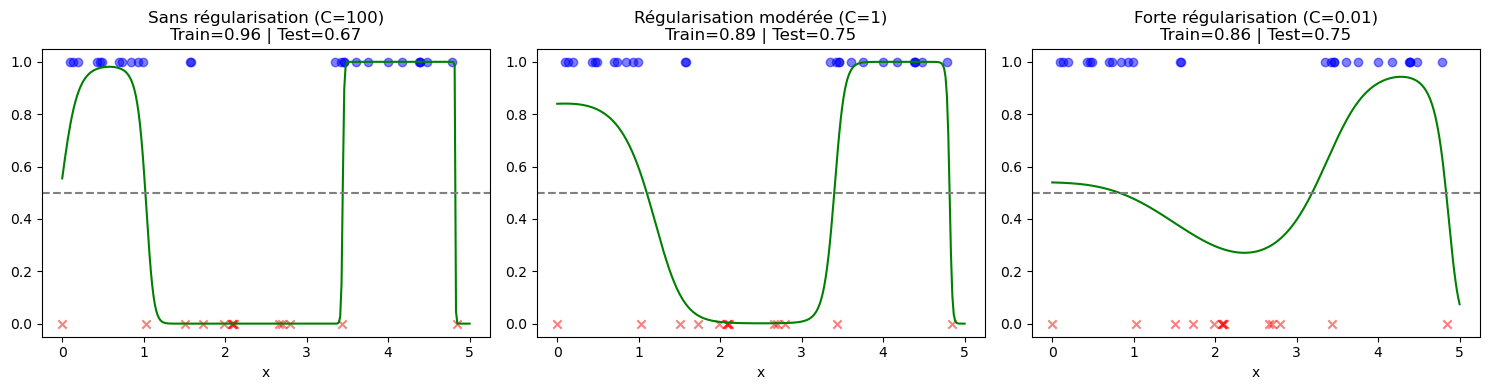

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    ("Sans régularisation (C=100)",   100),
    ("Régularisation modérée (C=1)",    1),
    ("Forte régularisation (C=0.01)", 0.01)
]

for ax, (titre, C_val) in zip(axes, configs):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=6)),
        ('lr',   LogisticRegression(C=C_val, max_iter=10000))
    ])
    model.fit(X_tr, y_tr)
    proba  = model.predict_proba(x_plot)[:, 1]
    acc_tr = model.score(X_tr, y_tr)
    acc_te = model.score(X_te, y_te)

    ax.scatter(X_big[y_big==0], y_big[y_big==0],
               c='red',  marker='x', alpha=0.5)
    ax.scatter(X_big[y_big==1], y_big[y_big==1],
               c='blue', marker='o', alpha=0.5)
    ax.plot(x_plot, proba, c='green')
    ax.axhline(y=0.5, color='gray', linestyle='--')
    ax.set_title(f"{titre}\nTrain={acc_tr:.2f} | Test={acc_te:.2f}")
    ax.set_xlabel('x')

plt.tight_layout() ; plt.show()

# Réponses :
# - C=100 : overfitting → courbe très irrégulière, train ≈ 1.0 mais test bas
# - C=0.01 : underfitting → courbe trop lisse, ne capture pas bien les données
# - C=1 : meilleur compromis train/test
# - Conclusion sur λ : λ contrôle la complexité du modèle.
#   Grand λ (petit C) → modèle simple, petit λ (grand C) → modèle complexe

In [35]:
#part 9

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

digits = load_digits()
X, y = digits.data, digits.target
print(f"Nombre d'exemples  : {X.shape[0]}")
print(f"Nombre de features : {X.shape[1]}")
print(f"Classes            : {np.unique(y)}")
print(f"Taille d'une image : 8x8 pixels")

Nombre d'exemples  : 1797
Nombre de features : 64
Classes            : [0 1 2 3 4 5 6 7 8 9]
Taille d'une image : 8x8 pixels


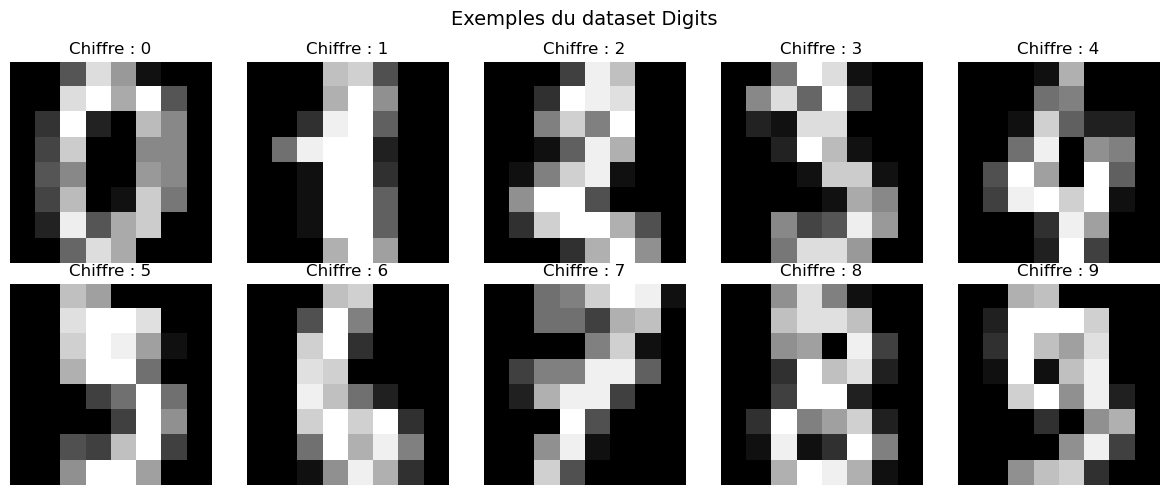

In [36]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, img, label in zip(axes.flatten(),
                           digits.images[:10],
                           digits.target[:10]):
    ax.imshow(img, cmap='gray')                  # ✅ afficher l'image
    ax.set_title(f"Chiffre : {label}")           # ✅ titre = étiquette
    ax.axis('off')

plt.suptitle("Exemples du dataset Digits", fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Taille train : {X_train.shape[0]} exemples")
print(f"Taille test  : {X_test.shape[0]} exemples")
# Attendu : 1437 train | 360 test

Taille train : 1437 exemples
Taille test  : 360 exemples


In [38]:
# ✅ SOLUTION
model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
model_ova.fit(X_train, y_train)

C:\Users\diikr\Downloads\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'ovr'


In [39]:
# ✅ SOLUTION
y_pred_ova = model_ova.predict(X_test)                  # prédire
acc_ova    = model_ova.score(X_test, y_test)            # accuracy

print(f"Accuracy One-vs-All : {acc_ova * 100:.2f}%")
# Résultat attendu : ~95%

Accuracy One-vs-All : 96.67%


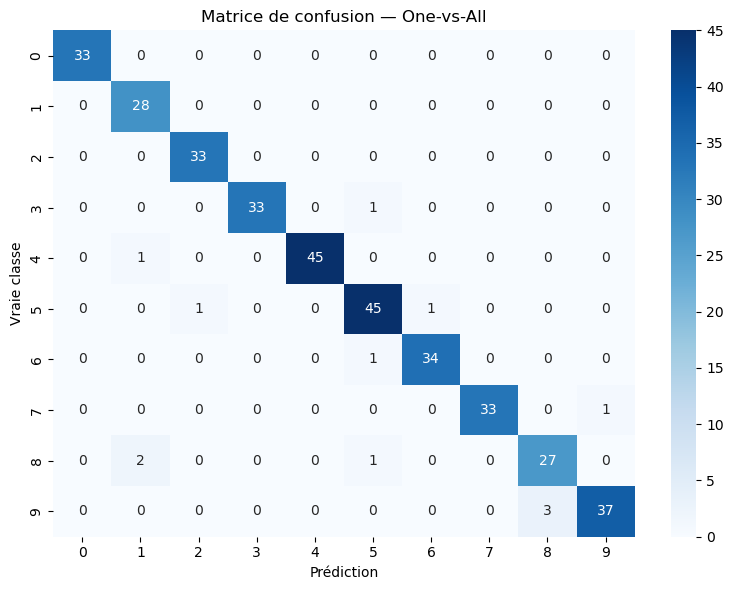

In [40]:
cm_ova = confusion_matrix(y_test, y_pred_ova)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_ova, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vraie classe')
ax.set_title('Matrice de confusion — One-vs-All')
plt.tight_layout()
plt.show()

# Réponses :
# - Chiffres mieux reconnus : 0, 1, 4 (valeurs élevées sur la diagonale)
# - Plus souvent confondus : 3 ↔ 8, 1 ↔ 7, 5 ↔ 9
#   car ils ont des formes visuellement similaires

In [41]:
# ✅ SOLUTION
model_softmax = LogisticRegression(multi_class='multinomial',
                                    solver='lbfgs',
                                    max_iter=1000)
model_softmax.fit(X_train, y_train)   # ✅ entraîner

C:\Users\diikr\Downloads\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [42]:
# ✅ SOLUTION
y_pred_sm = model_softmax.predict(X_test)          # prédire
acc_sm    = model_softmax.score(X_test, y_test)    # accuracy

print(f"Accuracy One-vs-All : {acc_ova * 100:.2f}%")
print(f"Accuracy Softmax    : {acc_sm  * 100:.2f}%")

Accuracy One-vs-All : 96.67%
Accuracy Softmax    : 97.50%


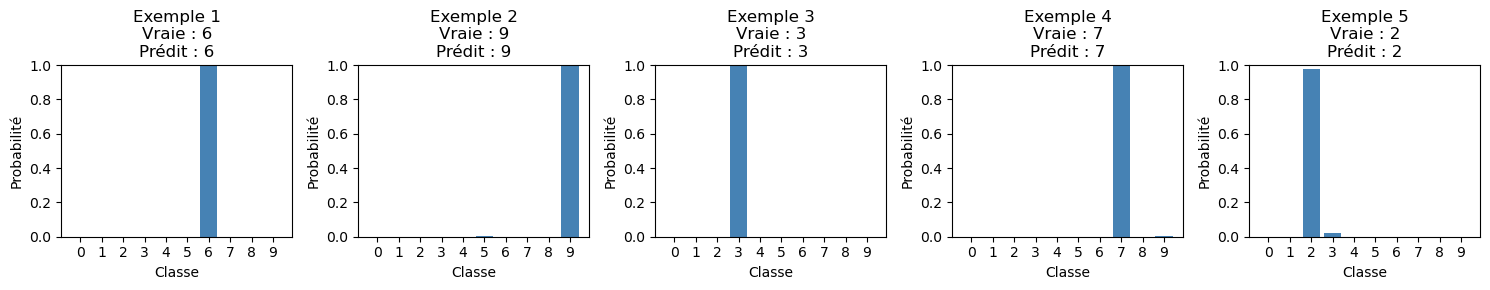

In [43]:
probas = model_softmax.predict_proba(X_test[:5])

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (ax, proba) in enumerate(zip(axes, probas)):
    ax.bar(range(10), proba, color='steelblue')
    ax.set_xticks(range(10))
    ax.set_xlabel('Classe')
    ax.set_ylabel('Probabilité')
    ax.set_title(f"Exemple {i+1}\nVraie : {y_test[i]}\nPrédit : {y_pred_sm[i]}")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Réponses :
# - Pour les exemples bien classifiés, P(bonne classe) est proche de 1
# - Pour un exemple mal classifié, deux barres sont élevées
#   (le modèle hésite entre 2 classes)

In [44]:
print(f"\n{'Modèle':<20} {'Accuracy Train':<18} {'Accuracy Test'}")
print("-" * 55)
for nom, model in [("One-vs-All", model_ova), ("Softmax", model_softmax)]:
    acc_tr = model.score(X_train, y_train)
    acc_te = model.score(X_test,  y_test)
    print(f"{nom:<20} {acc_tr:<18.4f} {acc_te:.4f}")

# Tableau récapitulatif complété :
# Probabilités Softmax    → Somment toujours à 1
# Accuracy test           → Softmax légèrement meilleur (~96% vs ~95%)


Modèle               Accuracy Train     Accuracy Test
-------------------------------------------------------
One-vs-All           0.9965             0.9667
Softmax              1.0000             0.9750


Nombre d'erreurs : 9 / 360


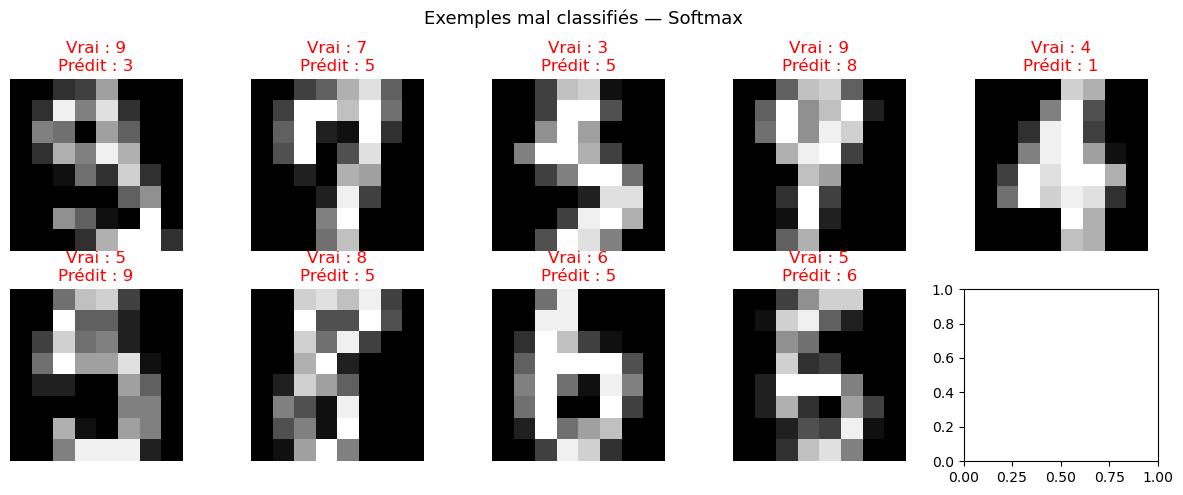

In [46]:
erreurs = np.where(y_pred_sm != y_test)[0]
print(f"Nombre d'erreurs : {len(erreurs)} / {len(y_test)}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, idx in zip(axes.flatten(), erreurs[:10]):
    ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"Vrai : {y_test[idx]}\nPrédit : {y_pred_sm[idx]}",
                 color='red')
    ax.axis('off')

plt.suptitle("Exemples mal classifiés — Softmax", fontsize=13)
plt.tight_layout()
plt.show()

# Réponses :
# - Oui, certaines erreurs sont compréhensibles visuellement :
#   ex. un 4 mal écrit ressemble à un 9, un 8 ressemble à un 3
# - Pour améliorer : utiliser un réseau de neurones convolutionnel (CNN)
#   qui capture mieux les patterns spatiaux des images
